In [23]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re


# Light curves live in ../transit_lightcurves/, one level up from this notebook's transit_disks/ folder
directory = '../transit_lightcurves/1_200G_4376.5109_4377.4913_fac_lat0_long0_r15_v4000_i90/'

#band
#directory = '../transit_lightcurves/1_4376.5109_4377.4913_band_lat45_90_v4000'




# print the header of the first file to get the simulation parameters
first_csv = next(Path('.').glob(f'{directory}/transit_lc*.csv'), None)
if first_csv:
    with open(first_csv, 'r') as f:
        header = f.readline()
        print("Simulation Parameters:")
        print(header.strip())
        print(' ')
else:
    print("No .csv files found to read the header from.")

lightcurves = {}
# read all the csv files in the directory and store the light curves in a dictionary based on wavelength
for csv_file in Path(directory).glob('transit_lc*.csv'):
    # Extract the wavelength from the filename using regex
    match = re.search(r'transit_lc_(\d+\.?\d*)\.csv', csv_file.name)
    if match:
        wavelength = float(match.group(1))
        data = np.loadtxt(csv_file, delimiter=',', skiprows=1)
        lightcurves[wavelength] = data
    else:
        print(f"Could not extract wavelength from filename: {csv_file.name}")

No .csv files found to read the header from.


In [14]:
print(lightcurves.keys())

dict_keys([])


In [15]:
plt.plot(np.arange(len(lightcurves[4376.5109])), lightcurves[4376.5109], label='4376.5109 Å')
plt.xlabel('Time (days)')
plt.ylabel('Relative Flux')
plt.title('Transit Light Curve')
plt.legend()
plt.show()

KeyError: 4376.5109

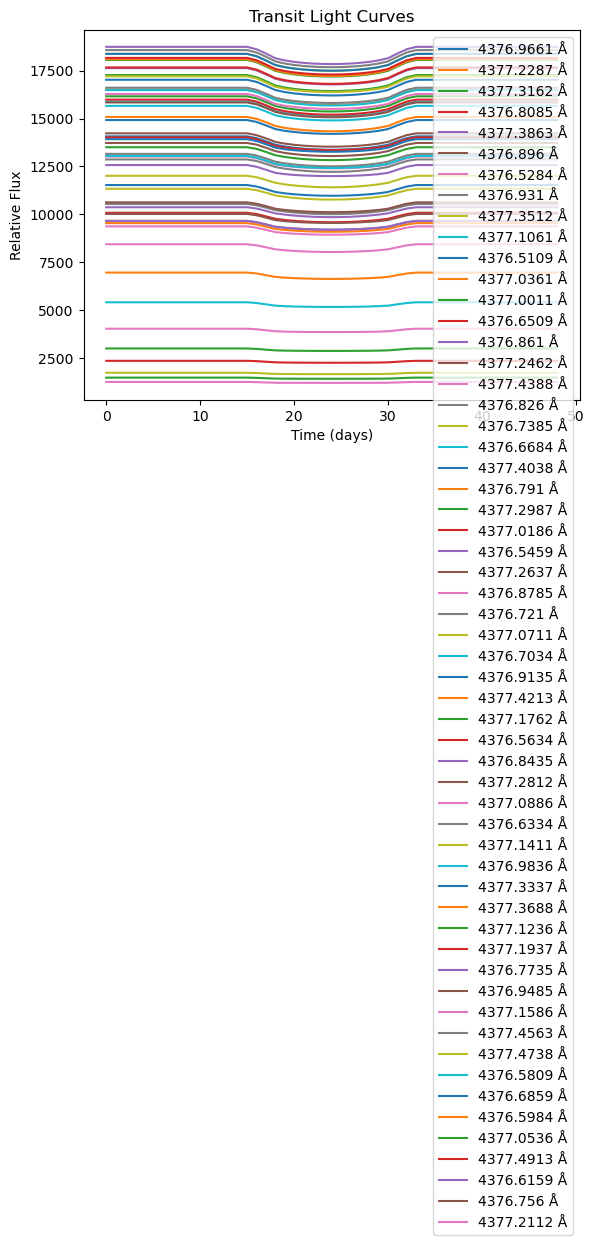

In [ ]:
#plot all the lightcurves on the same plot
for wavelength, data in lightcurves.items():
    plt.plot(np.arange(len(data)), data, label=f'{wavelength} Å')
plt.xlabel('Time (days)')
plt.ylabel('Relative Flux')
plt.title('Transit Light Curves')
plt.legend()
plt.show()

## Doppler shift across the transit

The cells below read the per-wavelength `transit_disk_inp*.npy` / `wavelength_shifts_inp*.csv` / `transit_positions_inp*.csv`
files written by `transit_disk_save` (see `simulator.py`'s `transit_lc(..., returndisc=True, v_eq=...)`).
Each disc stack has shape `(N_position, H, W)`, one frame per transit time-step, with the planet's shadow
already masked out and (if `v_eq!=0`) the star rotating between frames.

This mirrors `1_analyze_disks.ipynb`'s per-pixel Doppler-shifted spectrum, but repeated at every transit
position instead of a single phase, and finishes with a spectrum-vs-time "Doppler shadow" plot showing how
the planet's shadow moves across the rotationally broadened line profile as it transits.

In [32]:
# Point this at the directory passed to transit_disk_save (these live in this notebook's
# transit_disks/ folder)
transit_directory = './1_200G_4376.5109_4377.4913_fac_lat0_long0_r15_v4000_i90/'

disc_files = sorted(Path(transit_directory).glob('transit_disk_inp*.npy'))
if not disc_files:
    raise FileNotFoundError(f"No files found matching pattern: transit_disk_inp*.npy in {transit_directory}")

def parse_wavelength(p):
    m = re.search(r'inp([0-9.]+)\.npy$', p.name)
    return float(m.group(1)) if m else np.nan

transit_discs = {}
for f in disc_files:
    wl = parse_wavelength(f)
    transit_discs[wl] = np.load(f)

wavelengths_t = np.array(sorted(transit_discs.keys()))

shapes = {arr.shape for arr in transit_discs.values()}
if len(shapes) == 1:
    all_transit_discs = np.stack([transit_discs[wl] for wl in wavelengths_t], axis=0)
    # all_transit_discs shape: (num_wavelengths, num_positions, H, W)
    print("Stacked shape (Wavelength, Position, H, W):", all_transit_discs.shape)
else:
    raise ValueError("Shapes differ across wavelength files; every wavelength should share the same N/res2d.")

print(f"Loaded {len(transit_discs)} wavelength files")

Stacked shape (Wavelength, Position, H, W): (57, 49, 60, 60)
Loaded 57 wavelength files


wavelength_shifts_t shape (Wavelength, H, W): (57, 60, 60)
Planet positions shape (Position, 2): (49, 2)


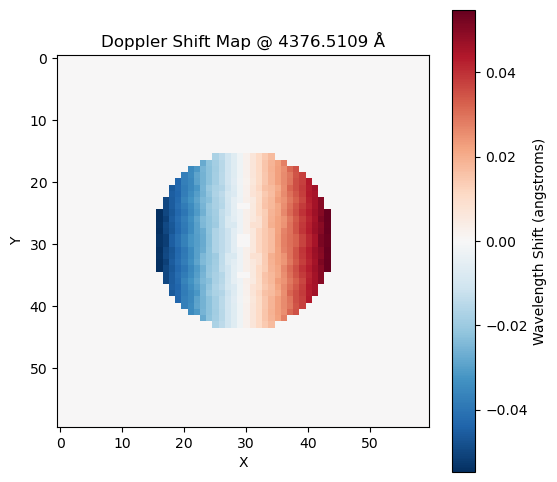

In [33]:
# Load the Doppler wavelength-shift map (one static map per wavelength, from the star's rotation) and the
# planet's (x, y) position at each transit time-step
shift_files = sorted(Path(transit_directory).glob('wavelength_shifts_inp*.csv'))
if not shift_files:
    raise FileNotFoundError("No files found matching pattern: wavelength_shifts_inp*.csv. "
                             "(This only gets written when transit_lc was run with v_eq!=0.)")

def parse_shift_wavelength(p):
    m = re.search(r'inp([0-9.]+)\.csv$', p.name)
    return float(m.group(1)) if m else np.nan

wavelength_shifts_by_wl = {}
for f in shift_files:
    wl = parse_shift_wavelength(f)
    wavelength_shifts_by_wl[wl] = np.loadtxt(f)

missing = [wl for wl in wavelengths_t if wl not in wavelength_shifts_by_wl]
if missing:
    raise ValueError(f"Missing shift maps for wavelengths: {missing}")

wavelength_shifts_t = np.stack([wavelength_shifts_by_wl[wl] for wl in wavelengths_t], axis=0)
print("wavelength_shifts_t shape (Wavelength, H, W):", wavelength_shifts_t.shape)

# Planet position is identical at a given transit index regardless of wavelength, so just read one file
pos_file = next(Path(transit_directory).glob('transit_positions_inp*.csv'))
positions = np.loadtxt(pos_file)
n_positions = positions.shape[0]
print("Planet positions shape (Position, 2):", positions.shape)

plt.figure(figsize=(6, 6))
plt.imshow(wavelength_shifts_t[0], cmap='RdBu_r')
plt.colorbar(label='Wavelength Shift (angstroms)')
plt.title(f'Doppler Shift Map @ {wavelengths_t[0]} Å')
plt.xlabel('X'); plt.ylabel('Y')
plt.show()

Example @ 4376.5109: (49, 60, 60, 2)
Per-wavelength shape: (Position, H, W, C), channels: 0=intensity, 1=wavelength_shift_in_m


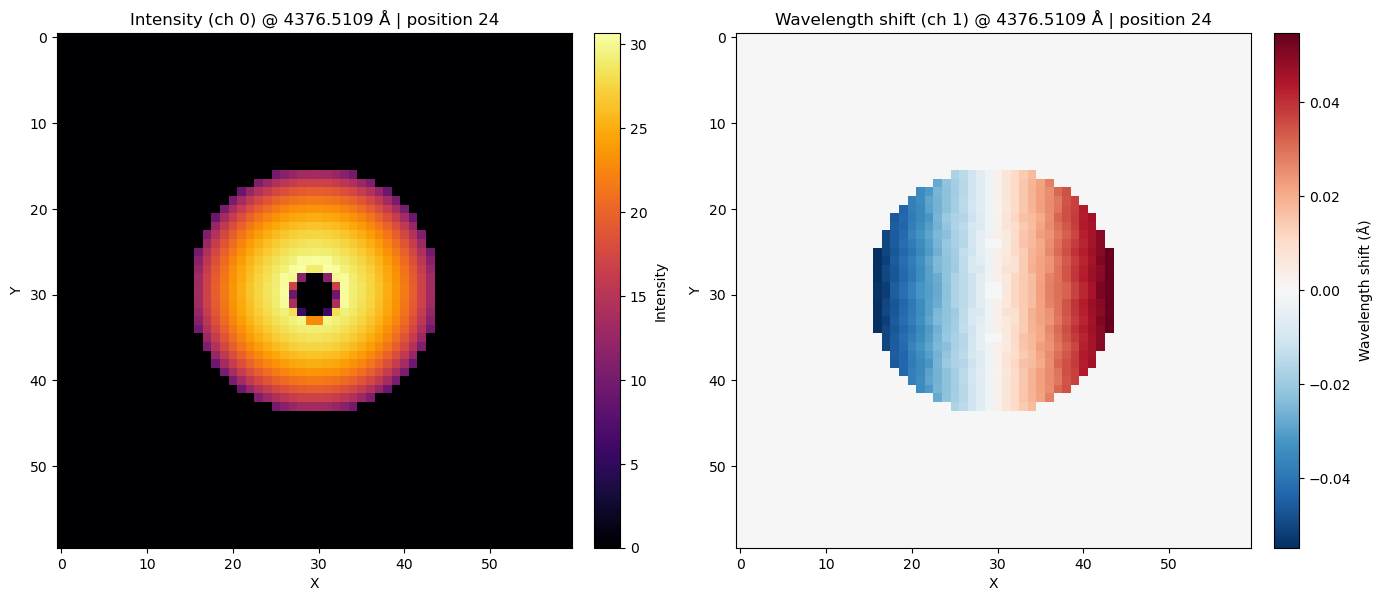

In [34]:
# Combine intensity + wavelength-shift channel per wavelength: (Position, H, W, C)
# channel 0 = intensity (with the planet's shadow already blocked out), channel 1 = wavelength shift (A)
all_transit_with_shift_by_wl = {
    wl: np.stack(
        [
            transit_discs[wl],
            np.broadcast_to(wavelength_shifts_by_wl[wl], transit_discs[wl].shape),
        ],
        axis=-1,
    )
    for wl in wavelengths_t
}

first_wl = wavelengths_t[0]
print(f"Example @ {first_wl}:", all_transit_with_shift_by_wl[first_wl].shape)
print("Per-wavelength shape: (Position, H, W, C), channels: 0=intensity, 1=wavelength_shift_in_m")

# --- Show the two channels side by side, each with its own colour bar ---
wl_show = first_wl
pos_show = n_positions // 2   # mid-transit, so the planet's shadow sits on the disc

intensity = all_transit_with_shift_by_wl[wl_show][pos_show, :, :, 0]
shift = all_transit_with_shift_by_wl[wl_show][pos_show, :, :, 1]

fig, (ax_int, ax_shift) = plt.subplots(1, 2, figsize=(14, 6))

# Channel 0: intensity -- sequential colour map.
im_int = ax_int.imshow(intensity, cmap='inferno')
ax_int.set_title(f'Intensity (ch 0) @ {wl_show} Å | position {pos_show}')
ax_int.set_xlabel('X'); ax_int.set_ylabel('Y')
fig.colorbar(im_int, ax=ax_int, label='Intensity', fraction=0.046, pad=0.04)

# Channel 1: wavelength shift -- diverging map centred on zero (same units as the
# wavelength filenames, i.e. Angstroms, matching cell 6's map).
vmax = np.abs(shift).max()
im_shift = ax_shift.imshow(shift, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax_shift.set_title(f'Wavelength shift (ch 1) @ {wl_show} Å | position {pos_show}')
ax_shift.set_xlabel('X'); ax_shift.set_ylabel('Y')
fig.colorbar(im_shift, ax=ax_shift, label='Wavelength shift (Å)', fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()

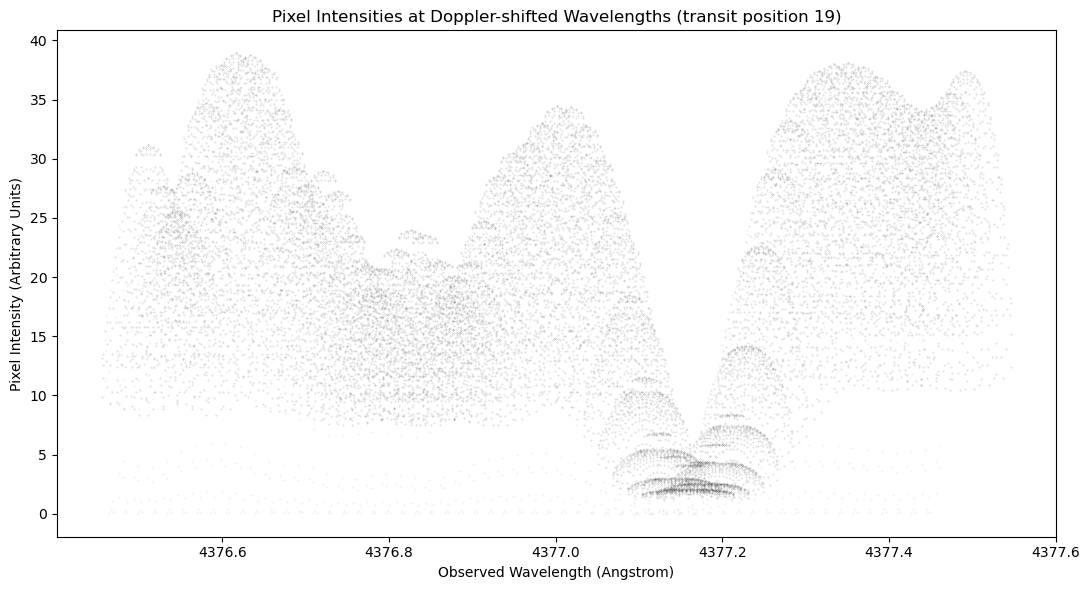

Num pixel points: 36195


In [35]:
# Per-pixel Doppler-shifted spectrum at a single transit time-step (same idea as 1_analyze_disks.ipynb's
# phase-0 scatter, just reusable for any transit position)
shift_scale = 1  # shift maps are stored in the same units as the wavelength filenames

def doppler_shifted_spectrum(position_idx):
    shifted_lambda_all = []
    intensity_all = []
    for wl in wavelengths_t:
        arr = all_transit_with_shift_by_wl[wl]
        intensity_2d = arr[position_idx, :, :, 0]
        dlam_2d = arr[position_idx, :, :, 1] * shift_scale
        lam_obs = wl + dlam_2d
        m = intensity_2d > 0  # keep only on-disc, unblocked pixels
        shifted_lambda_all.append(lam_obs[m].ravel())
        intensity_all.append(intensity_2d[m].ravel())
    return np.concatenate(shifted_lambda_all), np.concatenate(intensity_all)

position_idx = 19#n_positions // 2  # a time-step near mid-transit
shifted_lambda_all, intensity_all = doppler_shifted_spectrum(position_idx)

plt.figure(figsize=(11, 6))
plt.scatter(shifted_lambda_all, intensity_all, s=.1, alpha=0.1, color='black')
plt.xlabel('Observed Wavelength (Angstrom)')
plt.ylabel('Pixel Intensity (Arbitrary Units)')
plt.title(f'Pixel Intensities at Doppler-shifted Wavelengths (transit position {position_idx})')
plt.tight_layout()
plt.show()

print('Num pixel points:', shifted_lambda_all.size)

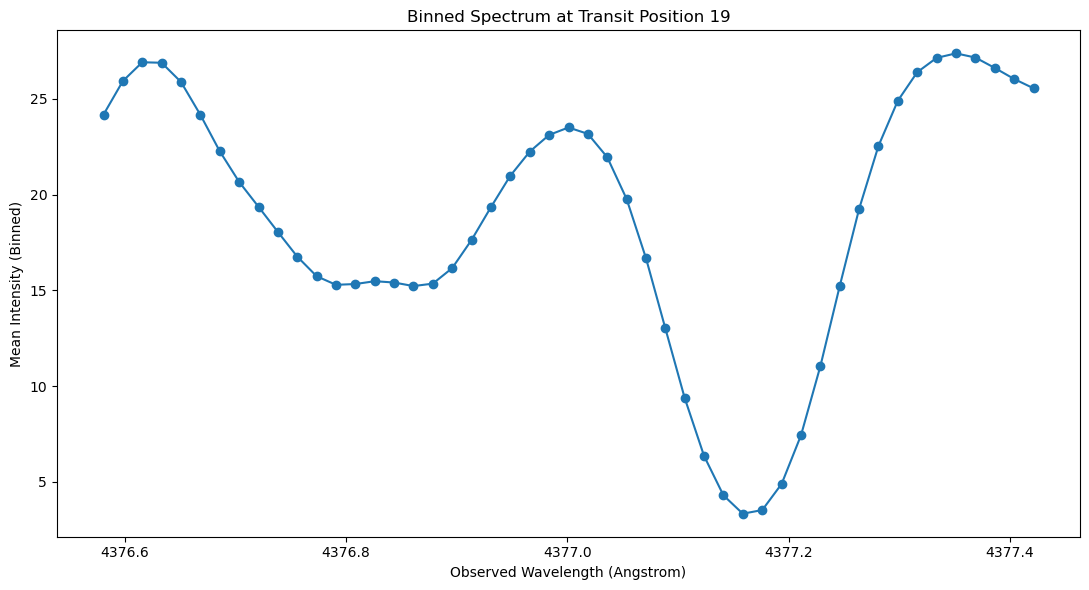

Number of valid bins: 49


In [36]:
# Bin the scattered pixel intensities onto the same wavelength grid as the input files (same edge-handling
# as 1_analyze_disks.ipynb, dropping bins within max_shift of either edge where the shift correction is
# incomplete)
max_shift = np.abs(wavelength_shifts_t).max()
wl_min_edge = wavelengths_t.min() + max_shift
wl_max_edge = wavelengths_t.max() - max_shift

midpoints = [(wavelengths_t[i] + wavelengths_t[i + 1]) / 2 for i in range(len(wavelengths_t) - 1)]
left_edge = wavelengths_t[0] - (midpoints[0] - wavelengths_t[0])
right_edge = wavelengths_t[-1] + (wavelengths_t[-1] - midpoints[-1])
bin_edges_t = np.array([left_edge, *midpoints, right_edge], dtype=float)

valid_bins_mask = (bin_edges_t[:-1] >= wl_min_edge) & (bin_edges_t[1:] <= wl_max_edge)
bin_centers_t = wavelengths_t[valid_bins_mask]
valid_indices_t = np.where(valid_bins_mask)[0]

if len(bin_centers_t) == 0:
    raise ValueError(
        "No valid wavelength bins survived edge-trimming: the wavelength window "
        f"({wavelengths_t.min():.4f}-{wavelengths_t.max():.4f} A) is too narrow relative to "
        f"the Doppler shift range (+/-{max_shift:.4f} A). Use a wider wavelength grid, "
        "or a lower v_eq, or fewer edge wavelengths."
    )

def binned_spectrum(position_idx):
    shifted_lambda, intensity = doppler_shifted_spectrum(position_idx)
    binned = np.full(len(bin_centers_t), np.nan)
    for i, idx in enumerate(valid_indices_t):
        mask = (np.round(shifted_lambda, 10) >= np.round(bin_edges_t[idx], 10)) & \
               (np.round(shifted_lambda, 10) < np.round(bin_edges_t[idx + 1], 10))
        if mask.any():
            binned[i] = intensity[mask].sum() / mask.sum()
    return binned

spec_mid = binned_spectrum(position_idx)
plt.figure(figsize=(11, 6))
plt.plot(bin_centers_t, spec_mid, marker='o', linestyle='-', linewidth=1.5)
plt.xlabel('Observed Wavelength (Angstrom)')
plt.ylabel('Mean Intensity (Binned)')
plt.title(f'Binned Spectrum at Transit Position {position_idx}')
plt.tight_layout()
plt.show()

print(f'Number of valid bins: {len(bin_centers_t)}')

spectrum_vs_time shape (Position/Time, Wavelength bin): (49, 49)


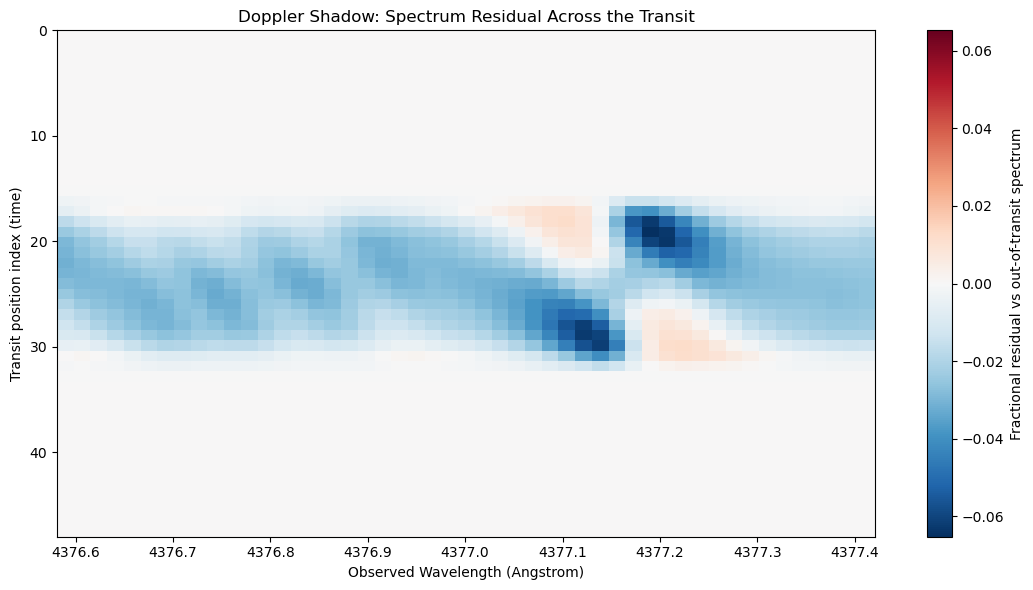

In [37]:
# Doppler shadow: binned spectrum at every transit time-step, stacked over time, shown relative to the
# out-of-transit (first position) spectrum. The planet blocks a different rotationally Doppler-shifted
# patch of the star at each time-step, so its shadow traces a moving feature in wavelength as time advances.
spectrum_vs_time = np.array([binned_spectrum(i) for i in range(n_positions)])
print("spectrum_vs_time shape (Position/Time, Wavelength bin):", spectrum_vs_time.shape)

baseline = spectrum_vs_time[0]  # first time-step, planet fully off the disc
residual = (spectrum_vs_time - baseline) / baseline

time_axis = np.arange(n_positions)  # swap for a physical time axis (e.g. from the transit_lc t array) if needed

vmax = np.nanmax(np.abs(residual))
plt.figure(figsize=(11, 6))
extent = [bin_centers_t.min(), bin_centers_t.max(), time_axis.max(), time_axis.min()]
im = plt.imshow(residual, aspect='auto', extent=extent, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
plt.colorbar(im, label='Fractional residual vs out-of-transit spectrum')
plt.xlabel('Observed Wavelength (Angstrom)')
plt.ylabel('Transit position index (time)')
plt.title('Doppler Shadow: Spectrum Residual Across the Transit')
plt.tight_layout()
plt.show()

In [38]:
# Animated version of the "Binned Spectrum at Transit Position 19" plot above: one frame per transit
# position, so the planet's shadow can be watched sweeping across the rotationally broadened line profile.
# The left panel shows the same time-step's stellar disc in pixel intensities, with the planet's shadow
# (already masked out of the disc stacks) crossing it.
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML, display

gif_path = 'binned_spectrum_across_transit.gif'
html_path = 'binned_spectrum_across_transit.html'
fps = 5

# to_jshtml() below embeds every frame as a base64 PNG; lift the default 20 MB cap
plt.rcParams['animation.embed_limit'] = 100  # MB

# spectrum_vs_time (cell above) already holds binned_spectrum(i) for every position; recompute only if needed
if 'spectrum_vs_time' not in globals():
    spectrum_vs_time = np.array([binned_spectrum(i) for i in range(n_positions)])

baseline_spec = spectrum_vs_time[0]  # out-of-transit reference, planet fully off the disc

# Fixed axes across all frames so the shadow's motion is the only thing that moves
ymin = np.nanmin(spectrum_vs_time)
ymax = np.nanmax(spectrum_vs_time)
pad = 0.05 * (ymax - ymin)

# Broadband-ish disc image per position: average the intensity channel over all wavelengths
# (all_transit_discs is (Wavelength, Position, H, W) from the loading cell)
disc_vs_time = all_transit_discs.mean(axis=0)
disc_vmax = disc_vs_time.max()  # fixed colour scale so brightness changes are real, not autoscaling

fig, (ax_disc, ax) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [1, 2]})

im_disc = ax_disc.imshow(disc_vs_time[0], cmap='inferno', vmin=0, vmax=disc_vmax)
ax_disc.set_title('Disc intensity (mean over wavelengths)')
ax_disc.set_xlabel('X')
ax_disc.set_ylabel('Y')
fig.colorbar(im_disc, ax=ax_disc, label='Intensity', fraction=0.046, pad=0.04)

ax.plot(bin_centers_t, baseline_spec, color='0.7', linestyle='--', linewidth=1.2,
        label='out-of-transit (position 0)')
(line,) = ax.plot([], [], marker='o', linestyle='-', linewidth=1.5, color='C0', label='current position')
ax.set_xlim(bin_centers_t.min(), bin_centers_t.max())
ax.set_ylim(ymin - pad, ymax + pad)
ax.set_xlabel('Observed Wavelength (Angstrom)')
ax.set_ylabel('Mean Intensity (Binned)')
ax.legend(loc='lower right')
# Placeholder title set before tight_layout so the layout reserves room for it
title = ax.set_title(f'Binned Spectrum at Transit Position 0 / {n_positions - 1}')

fig.tight_layout()

def update(i):
    line.set_data(bin_centers_t, spectrum_vs_time[i])
    title.set_text(f'Binned Spectrum at Transit Position {i} / {n_positions - 1}')
    im_disc.set_data(disc_vs_time[i])
    return line, title, im_disc

anim = FuncAnimation(fig, update, frames=n_positions, blit=False)

# Interactive player: play / pause / step, a slider to scrub to any transit position, loop mode and a
# speed control. Pure JS embedded in the output, so it needs no ipywidgets, survives being saved into
# the .ipynb, and the .html file opens standalone in a browser.
player_html = anim.to_jshtml(fps=fps)
with open(html_path, 'w') as f:
    f.write(player_html)

anim.save(gif_path, writer=PillowWriter(fps=fps))   # plain gif kept for slides/papers
plt.close(fig)

print(f'Wrote {gif_path} and {html_path} ({n_positions} frames)')
display(HTML(player_html))

Wrote binned_spectrum_across_transit.gif and binned_spectrum_across_transit.html (49 frames)
